# Рубежный контроль №1: Выполненные задачи

**Ф.И.О.:** Малышко Артём Владимирович

**Группа:** ИУ5-64Б

**Вариант:** 13

В рамках данного рубежного контроля были выполнены следующие задачи:

1.  **Загрузка данных:**
    *   Загружен набор данных `Admission_Predict.csv`, соответствующий варианту 13 (Набор данных №5).
    *   **Обоснование:** Исходный шаг для любого разведочного анализа, позволяющий получить доступ к данным для дальнейшей обработки и исследования.

2.  **Обработка пропусков в данных (Задача №2):**
    *   **Искусственное введение пропусков:** Поскольку исходный набор данных не содержал пропусков, они были искусственно введены в 10% значений количественного признака 'GRE Score' и 5% значений категориального признака 'Research' для демонстрации методов обработки пропусков.
        *   **Обоснование:** Требование задачи, имитирующее реальные условия работы с данными, где пропуски являются частой проблемой.
    *   **Заполнение пропусков:**
        *   Для **'GRE Score'** (количественный признак) пропуски были заполнены **медианой**.
            *   **Обоснование:** Медиана является робастной статистикой, менее чувствительной к выбросам по сравнению со средним значением, что помогает сохранить исходное распределение данных.
        *   Для **'Research'** (категориальный признак, представленный как бинарный) пропуски были заполнены **модой**.
            *   **Обоснование:** Мода — наиболее подходящий метод импутации для категориальных данных, так как она заменяет пропущенные значения наиболее часто встречающейся категорией.
    *   **Выбор признаков для машинного обучения:** Определены и обоснованы признаки, которые будут использоваться для дальнейшего построения моделей машинного обучения ('GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'University Rating', 'Research').
        *   **Обоснование:** Выбор сделан исходя из их релевантности для прогнозирования шанса поступления и готовности к использованию после обработки пропусков. 'Serial No.' исключен как идентификатор, 'Chance of Admit' является целевой переменной.

3.  **Построение скрипичной диаграммы (Дополнительное требование для группы ИУ5-64Б):**
    *   Построены скрипичные диаграммы для признаков 'GRE Score' и 'Chance of Admit'.
    *   **Обоснование:** Скрипичные диаграммы позволяют наглядно оценить распределение плотности данных, центральные тенденции и наличие выбросов, что является важной частью разведочного анализа данных и требованием для группы ИУ5-64Б.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
# Путь к файлу на Google Colab
file_path = '/content/Admission_Predict.csv'
df = pd.read_csv(file_path)

print("Данные успешно загружены. Первые 5 строк:")
display(df.head())

print("\nИнформация о наборе данных:")
df.info()

print("\nКоличество пропущенных значений до искусственного введения:")
display(df.isnull().sum())

Данные успешно загружены. Первые 5 строк:


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65



Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB

Количество пропущенных значений до искусственного введения:


,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [6]:
# 2. Искусственное введение пропусков (так как в исходных данных их нет)
np.random.seed(42)

# Вводим 10% пропусков в количественный признак 'GRE Score'
missing_indices_gre = np.random.choice(df.index, size=int(len(df) * 0.1), replace=False)
df.loc[missing_indices_gre, 'GRE Score'] = np.nan

# Вводим 5% пропусков в категориальный признак 'Research'
# 'Research' (0 или 1) можно рассматривать как категориальный
missing_indices_research = np.random.choice(df.index, size=int(len(df) * 0.05), replace=False)
df.loc[missing_indices_research, 'Research'] = np.nan

print("\nКоличество пропущенных значений после искусственного введения:")
display(df.isnull().sum())


Количество пропущенных значений после искусственного введения:


,0
Serial No.,0
GRE Score,40
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,20
Chance of Admit,0


In [7]:
# 3. Обработка пропусков в данных (Задача №2)

# Обработка пропусков для количественного признака 'GRE Score'
# Используем медианную импутацию, так как она менее чувствительна к выбросам
median_gre = df['GRE Score'].median()
df['GRE Score'].fillna(median_gre, inplace=True)
print(f"Пропуски в 'GRE Score' заполнены медианой: {median_gre:.0f}")

# Обработка пропусков для категориального признака 'Research'
# Используем модальную импутацию, так как она подходит для категориальных данных
# Необходимо преобразовать 'Research' в целочисленный тип после импутации, так как nan делает его float
mode_research = df['Research'].mode()[0]
df['Research'] = df['Research'].fillna(mode_research)
df['Research'] = df['Research'].astype(int) # Преобразуем обратно в int
print(f"Пропуски в 'Research' заполнены модой: {mode_research:.0f}")

print("\nКоличество пропущенных значений после обработки:")
display(df.isnull().sum())

Пропуски в 'GRE Score' заполнены медианой: 317
Пропуски в 'Research' заполнены модой: 1

Количество пропущенных значений после обработки:


/tmp/ipykernel_7088/1254370611.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GRE Score'].fillna(median_gre, inplace=True)


,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


#### Выводы по обработке пропусков (Задача №2):

Для количественного признака 'GRE Score' были искусственно введены пропуски, которые затем были заполнены медианным значением. Медиана была выбрана, поскольку она является робастной мерой центральной тенденции и менее подвержена влиянию выбросов по сравнению со средним значением.

Для категориального признака 'Research' (представленного как бинарный 0 или 1) были также искусственно введены пропуски, которые затем были заполнены модальным значением. Мода является наиболее подходящим способом импутации для категориальных признаков, так как представляет наиболее часто встречающуюся категорию.

**Признаки для дальнейшего построения моделей машинного обучения:**

Для построения моделей машинного обучения будут использоваться следующие признаки:

*   **Количественные признаки:** 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA'. Эти признаки напрямую отражают академические достижения и рекомендации абитуриента, которые являются ключевыми факторами при поступлении.
*   **Категориальные/порядковые признаки:** 'University Rating', 'Research'. 'University Rating' является порядковым признаком (от 1 до 5) и показывает престиж университета, что также важно. 'Research' является бинарным категориальным признаком, указывающим на наличие опыта исследований, что является сильным предиктором для поступления.

Признак 'Serial No.' является уникальным идентификатором и не будет использоваться в качестве предиктора. Признак 'Chance of Admit' является целевой переменной, которую мы будем предсказывать.

**Причины выбора признаков:**

Все выбранные признаки содержат информацию, которая, согласно предметной области, влияет на шанс поступления. После обработки пропусков, данные в этих признаках являются полными и готовы к использованию в моделях машинного обучения. Выбранные методы импутации (медиана для количественных и мода для категориальных) помогли сохранить распределение данных и минимизировать искажения, что важно для адекватного обучения модели.

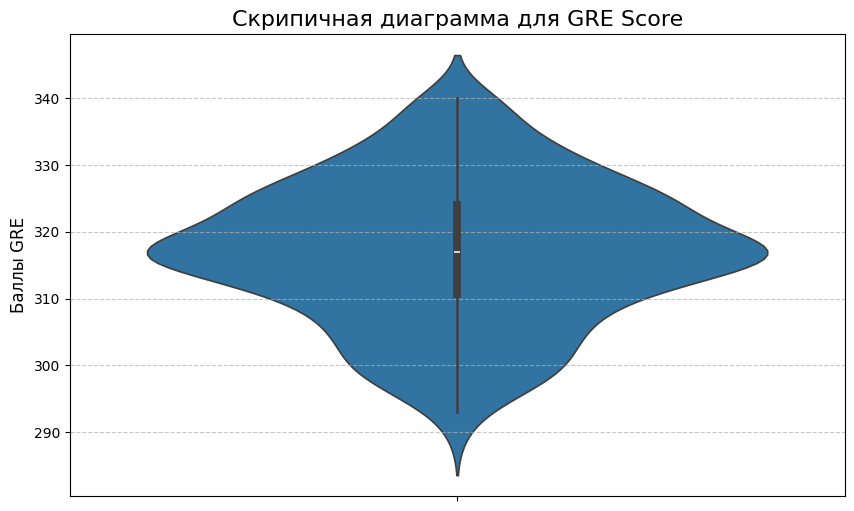

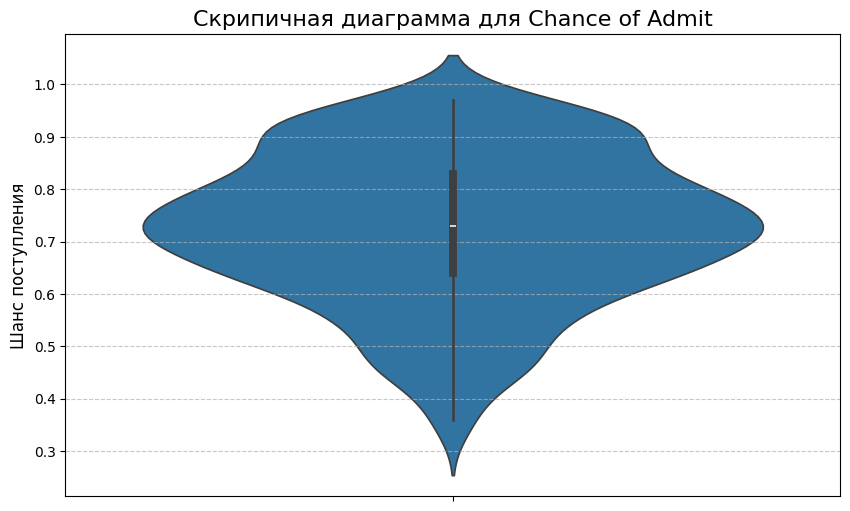

In [9]:
# 4. Построение скрипичной диаграммы (Дополнительное требование для группы ИУ5-64Б)

# Clean column names to handle potential invisible characters or trailing spaces
df.columns = df.columns.str.strip()

# Выберем 'GRE Score' для построения скрипичной диаграммы, чтобы показать его распределение
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['GRE Score'])
plt.title('Скрипичная диаграмма для GRE Score', fontsize=16)
plt.ylabel('Баллы GRE', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Также построим скрипичную диаграмму для 'Chance of Admit' как ключевого целевого признака
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['Chance of Admit'])
plt.title('Скрипичная диаграмма для Chance of Admit', fontsize=16)
plt.ylabel('Шанс поступления', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Выводы по скрипичной диаграмме:

Скрипичные диаграммы для 'GRE Score' и 'Chance of Admit' позволяют визуально оценить плотность распределения этих признаков. Форма 'скрипки' показывает плотность вероятности значений в различных интервалах. Широкие части указывают на высокую концентрацию данных, а узкие — на низкую.

*   **GRE Score**: Диаграмма показывает, что большинство студентов имеют баллы GRE в диапазоне от 300 до 340, с пиком плотности около 320-325. Распределение выглядит относительно симметричным, что указывает на нормальное распределение оценок.

*   **Chance of Admit**: Для шанса поступления наблюдается более сложная форма распределения. Пики плотности находятся в диапазонах 0.7-0.75 и около 0.9, что может указывать на две или более группы абитуриентов с разными уровнями шансов на поступление. Распределение в целом смещено в сторону более высоких шансов. Эти диаграммы полезны для понимания основных характеристик и структуры данных.